In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("C:\\Users\\Asus\\OneDrive\\Desktop\\power shheets\\Advertising.csv")
df.head()

,TV,radio,newspaper,sales
0,230100,37800,69200,22100
1,44500,39300,45100,10400
2,17200,45900,69300,9300
3,151500,41300,58500,18500
4,180800,10800,58400,12900


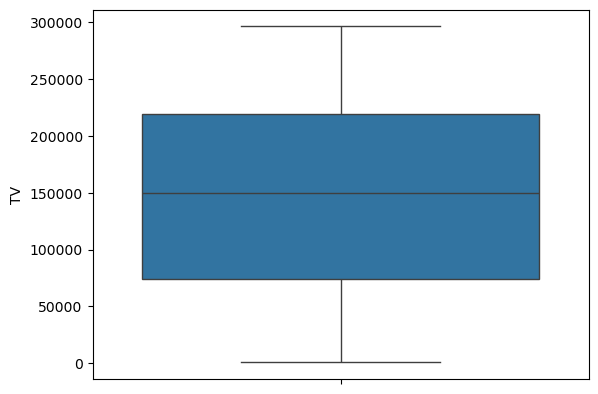

In [3]:
sns.boxplot(df['TV'])
plt.show()

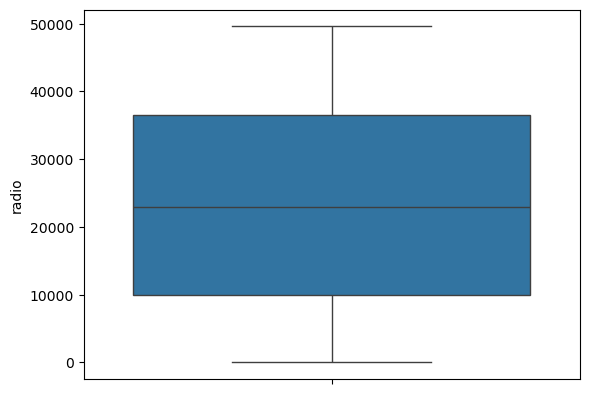

In [4]:
sns.boxplot(df['radio'])
plt.show()

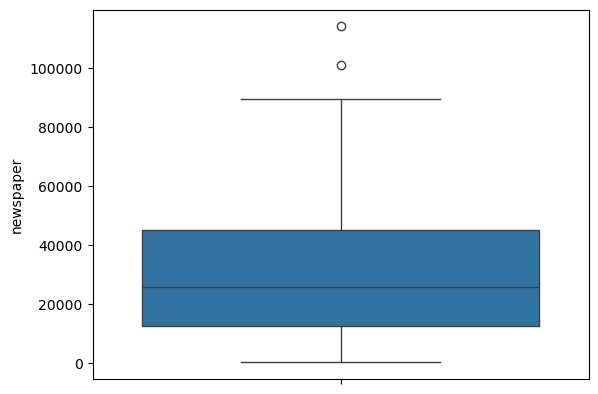

In [5]:
sns.boxplot(df['newspaper'])
plt.show()

In [6]:
# treat outliers
Q1=df['newspaper'].quantile(0.25)
print("Q1:",Q1)
Q3=df['newspaper'].quantile(0.75)
print("Q3:",Q3)
IQR = Q3-Q1
print("IQR:",IQR)

Q1: 12750.0
Q3: 45100.0
IQR: 32350.0


In [7]:
upper_limit=Q3+(1.5*IQR)
print("upper_limit",upper_limit)
lower_limit=Q1-(1.5*IQR)
print("lower_limit",lower_limit)

upper_limit 93625.0
lower_limit -35775.0


In [8]:
df_cleaned_iqr=df[(df['newspaper']<lower_limit)|(df['newspaper']>upper_limit)]

In [9]:
print(df_cleaned_iqr)        #Removing outliers

         TV  radio  newspaper  sales
16    67800  36600     114000  12500
101  296400  36300     100900  23800


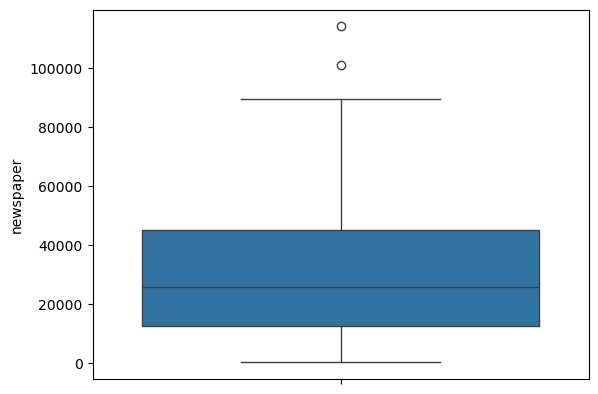

In [10]:
sns.boxplot(df['newspaper']) #After removing outliers
plt.show()

# X and y

In [12]:
X=df.drop('sales',axis=1)
y=df['sales']

In [13]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=10)

**Applying hyperparameter tuning for lasso regression**

In [15]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso
estimator = Lasso()
param_grid={'alpha':list(range(1,100))}
model_hp=GridSearchCV(estimator,param_grid,cv=5,scoring='r2')
model_hp.fit(X_train,y_train)
model_hp.best_params_

{'alpha': 1}

# Final Model

In [17]:
X=df.drop('sales',axis=1)
y=df['sales']

In [18]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=10)

In [19]:
from sklearn.linear_model import Lasso
best_model=Lasso(alpha=99)
best_model.fit(X_train,y_train)
print("Intercept:",best_model.intercept_)
print("Coeficent:",best_model.coef_)

Intercept: 3254.10308631925
Coeficent: [ 0.04377259  0.19343236 -0.00222844]


In [20]:
ypred_train=best_model.predict(X_train)

In [21]:
from sklearn.metrics import r2_score
print("R2 score:",r2_score(y_train,ypred_train))
from sklearn.model_selection import cross_val_score
print("Cross validation score:",cross_val_score(best_model,X_train,y_train,cv=5).mean())

R2 score: 0.9209087553457435
Cross validation score: 0.9157327584598697


In [22]:
ypred_test=best_model.predict(X_test)
from sklearn.metrics import r2_score
print("r2_score:",r2_score(y_test,ypred_test))
from sklearn.model_selection import cross_val_score
print("Cross validation score:",cross_val_score(best_model,X_test,y_test,cv=5).mean())

r2_score: 0.8353673246715815
Cross validation score: 0.24459728135163078


**Applying hyperparameter tuning for lasso regression**

In [82]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge
estimator = Ridge()
param_grid={'alpha':list(range(1,101))}
model_hp=GridSearchCV(estimator,param_grid,cv=5,scoring='r2')
model_hp.fit(X_train,y_train)
model_hp.best_params_

{'alpha': 1}

In [84]:
from sklearn.linear_model import Ridge
ridge_best_model=Ridge(alpha=1)
ridge_best_model.fit(X_train,y_train)
print("Intercept:",ridge_best_model.intercept_)
print("Coeficent:",ridge_best_model.coef_)

Intercept: 3254.0971145214207
Coeficent: [ 0.0437726   0.19343299 -0.00222879]


In [86]:
ypred_train=ridge_best_model.predict(X_train)

In [88]:
from sklearn.metrics import r2_score
print("R2 score:",r2_score(y_train,ypred_train))
from sklearn.model_selection import cross_val_score
print("Cross validation score:",cross_val_score(ridge_best_model,X_train,y_train,cv=5).mean())

R2 score: 0.9209087553499528
Cross validation score: 0.9157327701185005


In [90]:
ypred_test=ridge_best_model.predict(X_test)
from sklearn.metrics import r2_score
print("r2_score:",r2_score(y_test,ypred_test))
from sklearn.model_selection import cross_val_score
print("Cross validation score:",cross_val_score(ridge_best_model,X_test,y_test,cv=5).mean())

r2_score: 0.8353672324685251
Cross validation score: 0.2445977117158762


**Applying hyperparameter tuning for elasticnet regression**

In [93]:
X=df.drop('sales',axis=1)
y=df['sales']
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=8)
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import ElasticNet
estimator=ElasticNet()
param_grid={'alpha':list(range(1,101)),
            'l1_ratio':[0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1]}
model_hp=GridSearchCV(estimator,param_grid,cv=5,scoring='r2')
model_hp.fit(X_train,y_train)
model_hp.best_params_

C:\Users\Asus\AppData\Local\Programs\Orange\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.678e+08, tolerance: 3.208e+05 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
C:\Users\Asus\AppData\Local\Programs\Orange\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.476e+08, tolerance: 3.350e+05 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of th

{'alpha': 100, 'l1_ratio': 1}